### Validation Plotting

Training logs were lost due to a bug in the FileLogger. Hotfixing for weekly meeting: analyze passrates over validation logs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
root = "/ptmp/rfechner/out/exp01"
dirs = os.listdir(root)

logpaths = {
    d : os.path.join(root, d, 'logs.jsonl') for d in dirs
}

valpaths = [
    os.path.join(root, d, 'val_jsonl') for d in dirs
]

In [55]:
import pandas as pd
import numpy as np

In [ ]:
def mean_validation_score(filepath : str):
    
    precomputed_jsonfiles = list(filter(lambda x: 'precomp' in x, os.listdir(filepath)))
    jsonfiles = list(filter(lambda x: 'precomp' not in x, os.listdir(filepath)))
    precomputed_jsonfiles = list(sorted(precomputed_jsonfiles, key=lambda x: int(x.split('_')[0])))
    jsonfiles = list(sorted(jsonfiles, key=lambda x: int(x.split('.')[0])))
    
    precomputed_logprobs, precomputed_entropy, validation_means = [], [], {}
    
    for f in jsonfiles:
        with open(os.path.join(filepath, f)) as file:
            validation_means.append(
                pd.read_json(file, lines=True)['reward'].mean()
            )
    # god forgive my sins
    for f in precomputed_jsonfiles:
        with open(os.path.join(filepath, f)) as file:
            df = pd.read_json(file, lines=True)
            l, e = df['logprobs'], df['entropy']
            l1, l2 = np.array(l[0][:4]).mean(), np.array(l[0][4:]).mean()
            e1, e2 = np.array(e[0][:4]).mean(), np.array(e[0][4:]).mean()
            precomputed_logprobs.append(
                (l1+  l2) / 2
            )
            precomputed_entropy.append(
                (e1+  e2) / 2
            )
    return precomputed_logprobs, precomputed_entropy, validation_means

In [64]:
import pathlib
from tqdm import tqdm_notebook as tqdm

In [63]:
pathlib.Path(valpaths[0]).parts[-2]

'qwen3_0.6b__grpo'

In [71]:
def calc_method_metrics():
    metrics = {}
    for vp in tqdm(valpaths):
        method = pathlib.Path(vp).parts[-2]
        lp, e, valacc = mean_validation_score(vp)
        metrics[method] = {
            'logprobs' : lp,
            'entropy' : e,
            'valacc' : valacc
        }
    return metrics
metrics = calc_method_metrics()

/tmp/ipykernel_70648/4262499689.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for vp in tqdm(valpaths):


  0%|          | 0/8 [00:00<?, ?it/s]

In [72]:
metrics.keys()

dict_keys(['qwen3_0.6b__grpo', 'llama_3.2_1b_instruct__dapo', 'qwen3_0.6b__drgrpo', 'llama_3.2_1b_instruct__grpo', 'llama_3.2_1b_instruct__drgrpo', 'llama_3.2_1b_instruct__gspo', 'qwen3_0.6b__gspo', 'qwen3_0.6b__dapo'])

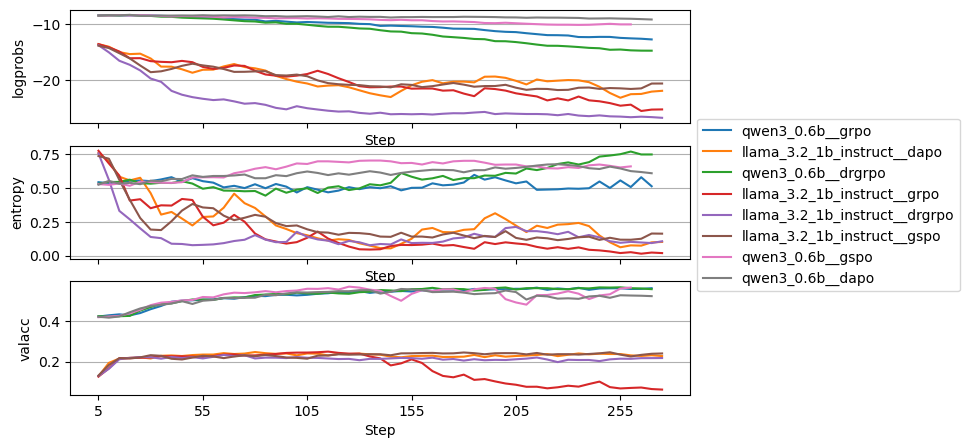

In [97]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)
keys = ['logprobs', 'entropy', 'valacc']
labels = {
    'logprobs' : "Log-probs for incorrect answer",
    "entropy" : "Entropy over incorrect tokens",
    "valacc" : "Mean validation accuracy over 5 Datasets"
}
xticks, xticks_values = range(0, 53, 10), range(5, 270, 50)

for i, key in enumerate(keys):
    for k, v in metrics.items():
        values = v[key]
        axes[i].plot(range(len(values)), values, label=k)
    axes[i].set_xticks(xticks, xticks_values)
    axes[i].set_ylabel(key)
    axes[i].set_xlabel('Step')
    axes[i].grid(visible=True, axis='y')
axes[-1].legend(bbox_to_anchor=(1, 2.5))
plt.plot()
plt.show()